# **Creating image using numpy**

In [5]:
import numpy as np

# Define normalized Haar wavelet filters
h = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)])  # Low-pass filter
g = np.array([1 / np.sqrt(2), -1 / np.sqrt(2)])  # High-pass filter

# Define the 2x2 image
image = np.array([[4, 2],
                  [5, 1]], dtype=np.float32)

# Forward 2D DWT
def dwt2(image):
    rows, cols = image.shape
    # Apply 1D DWT to rows
    row_transformed = np.zeros_like(image)
    for i in range(rows):
        row_transformed[i, :] = np.convolve(image[i, :], h, mode='valid')[::2]  # Approximation
        row_transformed[i, :] = np.convolve(image[i, :], g, mode='valid')[::2]  # Detail

    # Apply 1D DWT to columns
    LL = np.zeros((rows // 2, cols // 2))
    LH = np.zeros((rows // 2, cols // 2))
    HL = np.zeros((rows // 2, cols // 2))
    HH = np.zeros((rows // 2, cols // 2))
    for j in range(cols // 2):
        LL[:, j] = np.convolve(row_transformed[:, j], h, mode='valid')[::2]  # LL
        LH[:, j] = np.convolve(row_transformed[:, j], g, mode='valid')[::2]  # LH
        HL[:, j] = np.convolve(row_transformed[:, j + cols // 2], h, mode='valid')[::2]  # HL
        HH[:, j] = np.convolve(row_transformed[:, j + cols // 2], g, mode='valid')[::2]  # HH

    return LL, LH, HL, HH

# Inverse 2D DWT
def idwt2(LL, LH, HL, HH):
    rows, cols = LL.shape
    # Reconstruct columns
    reconstructed = np.zeros((rows * 2, cols * 2))
    for j in range(cols):
        reconstructed[:, j * 2] = np.convolve(LL[:, j], h, mode='full')[:rows * 2]  # LL
        reconstructed[:, j * 2 + 1] = np.convolve(LH[:, j], h, mode='full')[:rows * 2]  # LH
        reconstructed[:, j * 2] += np.convolve(HL[:, j], g, mode='full')[:rows * 2]  # HL
        reconstructed[:, j * 2 + 1] += np.convolve(HH[:, j], g, mode='full')[:rows * 2]  # HH

    # Reconstruct rows
    for i in range(rows * 2):
        reconstructed[i, :] = np.convolve(reconstructed[i, :], h, mode='full')[:cols * 2]  # LL + HL
        reconstructed[i, :] += np.convolve(reconstructed[i, :], g, mode='full')[:cols * 2]  # LH + HH

    return reconstructed

# Test the custom implementation
LL, LH, HL, HH = dwt2(image)
reconstructed_image = idwt2(LL, LH, HL, HH)

print("Original Image:\n", image)
print("\nLL (Approximation):\n", LL)
print("LH (Horizontal Detail):\n", LH)
print("HL (Vertical Detail):\n", HL)
print("HH (Diagonal Detail):\n", HH)
print("\nReconstructed Image:\n", reconstructed_image)

Original Image:
 [[4. 2.]
 [5. 1.]]

LL (Approximation):
 [[-2.99999995]]
LH (Horizontal Detail):
 [[-0.99999998]]
HL (Vertical Detail):
 [[-2.99999995]]
HH (Diagonal Detail):
 [[-0.99999998]]

Reconstructed Image:
 [[-5.12132026 -4.7071067 ]
 [ 0.          0.        ]]


# **Wavelet Transform for an image**

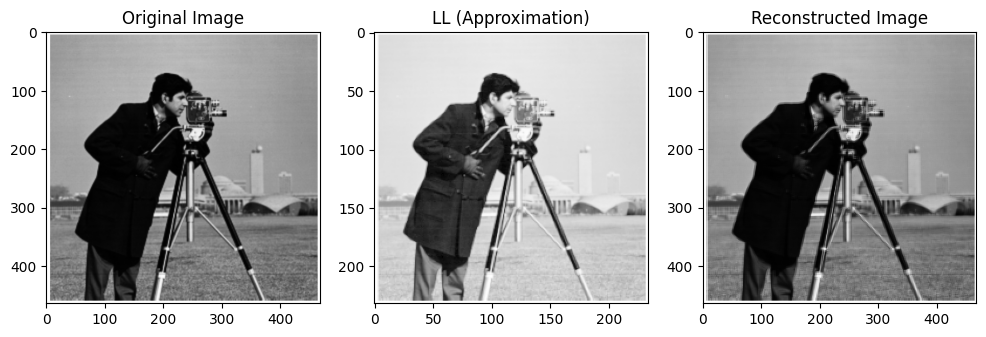

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Define Haar wavelet filters
h = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)])  # Low-pass filter
g = np.array([1 / np.sqrt(2), -1 / np.sqrt(2)])  # High-pass filter

# Load an image and convert to grayscale
def load_image(image_path):
    image = Image.open(image_path).convert('L')  # Convert to grayscale
    image = np.array(image, dtype=np.float32)
    return image

# Forward 2D DWT
def dwt2(image):
    rows, cols = image.shape
    row_low = np.zeros((rows, cols // 2))
    row_high = np.zeros((rows, cols // 2))

    for i in range(rows):
        row_low[i, :] = np.convolve(image[i, :], h, mode='valid')[::2]
        row_high[i, :] = np.convolve(image[i, :], g, mode='valid')[::2]

    LL = np.zeros((rows // 2, cols // 2))
    LH = np.zeros((rows // 2, cols // 2))
    HL = np.zeros((rows // 2, cols // 2))
    HH = np.zeros((rows // 2, cols // 2))

    for j in range(cols // 2):
        LL[:, j] = np.convolve(row_low[:, j], h, mode='valid')[::2]
        LH[:, j] = np.convolve(row_low[:, j], g, mode='valid')[::2]
        HL[:, j] = np.convolve(row_high[:, j], h, mode='valid')[::2]
        HH[:, j] = np.convolve(row_high[:, j], g, mode='valid')[::2]

    return LL, LH, HL, HH

# Inverse 2D DWT
def idwt2(LL, LH, HL, HH):
    rows, cols = LL.shape

    # Upsample columns before convolution
    up_LL = np.zeros((rows * 2, cols))
    up_LH = np.zeros((rows * 2, cols))
    up_HL = np.zeros((rows * 2, cols))
    up_HH = np.zeros((rows * 2, cols))

    up_LL[::2, :] = LL
    up_LH[::2, :] = LH
    up_HL[::2, :] = HL
    up_HH[::2, :] = HH

    col_low = np.zeros((rows * 2, cols))
    col_high = np.zeros((rows * 2, cols))

    for j in range(cols):
        col_low[:, j] = np.convolve(up_LL[:, j], h, mode='full')[:rows * 2] + np.convolve(up_LH[:, j], g, mode='full')[:rows * 2]
        col_high[:, j] = np.convolve(up_HL[:, j], h, mode='full')[:rows * 2] + np.convolve(up_HH[:, j], g, mode='full')[:rows * 2]

    # Upsample rows before convolution
    up_col_low = np.zeros((rows * 2, cols * 2))
    up_col_high = np.zeros((rows * 2, cols * 2))

    up_col_low[:, ::2] = col_low
    up_col_high[:, ::2] = col_high

    reconstructed = np.zeros((rows * 2, cols * 2))
    for i in range(rows * 2):
        reconstructed[i, :] = np.convolve(up_col_low[i, :], h, mode='full')[:cols * 2] + np.convolve(up_col_high[i, :], g, mode='full')[:cols * 2]

    return reconstructed

# Load an image
image_path = 'thr.png'  # Replace with your image path
image = load_image(image_path)

# Perform 2D DWT
LL, LH, HL, HH = dwt2(image)

# Perform Inverse 2D DWT
reconstructed_image = idwt2(LL, LH, HL, HH)

# Display the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(np.log1p(np.abs(LL)), cmap='gray')  # Log scale for better visualization
plt.title('LL (Approximation)')

plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')

plt.show()
